# 📘 AI/ML Assignment 3
## Supervised Learning Models in Practice

**Total Marks: 100**  
**Submission Format:** Single Jupyter Notebook (`.ipynb`)

---
## 📌 General Instructions (Read Carefully)

- This assignment covers **Modules 13–18**.
- Use **Python and scikit-learn only**.
- Do NOT use AutoML, deep learning, or external ML libraries.
- Fix `random_state=42` wherever applicable.
- Plots must be labeled and readable.
- Do not delete or rename cells.

***Classification Dataset:*** https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data/data

***Regresssion Dataset:*** https://www.kaggle.com/datasets/mirichoi0218/insurance

## 🔧 TODO 0: Environment Setup (5 Marks)
**Marks Breakdown:**
- Correct imports (3)
- Clean setup, no unused imports (2)


In [1]:
# TODO: Import all necessary libraries here
import warnings
import os
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay,
)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVR, LinearSVC
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

class ToDenseTransformer:
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        try:
            return X.toarray()
        except AttributeError:
            return X

def find_file(candidates):
    search_dirs = [Path('.').resolve(), Path.home() / 'Downloads', Path.cwd()]
    for candidate in candidates:
        if not isinstance(candidate, Path):
            candidate = Path(candidate)
        for d in search_dirs:
            p = d / candidate
            if p.exists():
                return p
    return None

def brief_df_info(df: pd.DataFrame, name: str = "DataFrame"):
    print(f"{name} shape: {df.shape}")
    print("Columns:", list(df.columns))


# 🔵 PART A: Regression Task (45 Marks)
You will work with the provided **regression dataset**.


## TODO A1: Dataset Loading and Understanding (5 Marks)
**You must:**
- Load the dataset
- Show shape and column names
- Identify target variable

**Marks:** Data loading (2), Explanation (3)


In [3]:
# TODO: Load regression dataset
# Expected file: insurance.csv (from Kaggle: mirichoi0218/insurance)
reg_candidates = [
    Path("insurance.csv"),
    Path("insurance/insurance.csv"),
]
reg_path = find_file(reg_candidates)

if reg_path is None:
    print(
        "Could not find 'insurance.csv'. Please download from Kaggle and place it "
        "in this notebook folder or your Downloads folder."
    )
else:
    reg_df = pd.read_csv(reg_path)
    brief_df_info(reg_df, "Regression (insurance)")
    target_reg = "charges" if "charges" in reg_df.columns else None
    print("Target variable:", target_reg)


Regression (insurance) shape: (1338, 7)
Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']
Target variable: charges


## TODO A2: Exploratory Data Analysis (EDA) (5 Marks)
**You must:**
- Show descriptive statistics
- Plot correlation heatmap
- Plot at least one feature vs target

**Marks:** Plots (3), Interpretation (2)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.0,NaN,NaN,NaN,39.207025,14.04996,18.0,27.0,39.0,51.0,64.0
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.0,NaN,NaN,NaN,30.663397,6.098187,15.96,26.29625,30.4,34.69375,53.13
children,1338.0,NaN,NaN,NaN,1.094918,1.205493,0.0,0.0,1.0,2.0,5.0
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.0,NaN,NaN,NaN,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


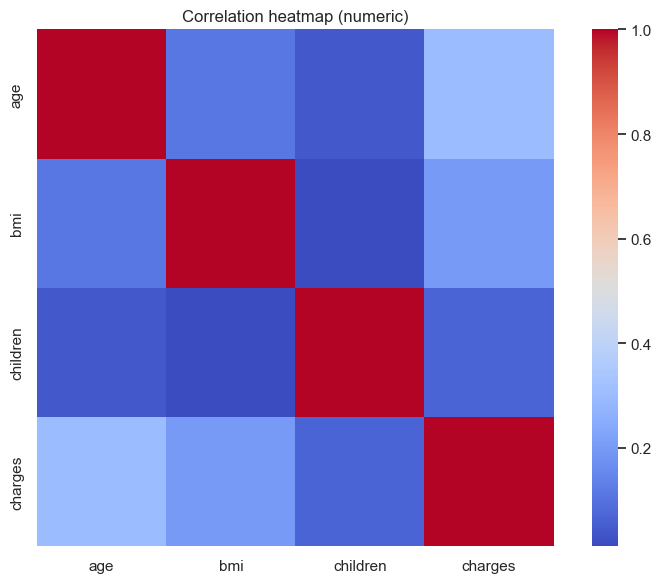

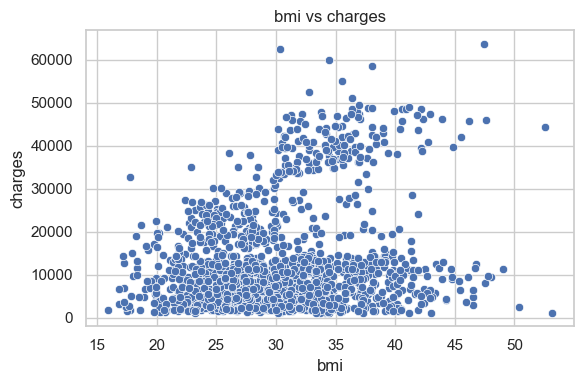

Observation: Typically, charges rise with BMI and smoking status.


In [4]:
# TODO: Perform EDA
if 'reg_df' in globals():
    display(reg_df.head())
    display(reg_df.describe(include='all').transpose())
    # Correlation heatmap for numeric features
    numeric = reg_df.select_dtypes(include='number')
    if numeric.shape[1] > 1:
        corr = numeric.corr()
        plt.figure(figsize=(8, 6))
        sns.heatmap(corr, annot=False, cmap='coolwarm', square=True)
        plt.title("Correlation heatmap (numeric)")
        plt.tight_layout()
        plt.show()
    # Plot one feature vs target
    target = 'charges' if 'charges' in reg_df.columns else None
    if target is not None:
        feat_for_plot = 'bmi' if 'bmi' in reg_df.columns else None
        if feat_for_plot is None:
            candidates = [c for c in numeric.columns if c != target]
            if candidates:
                feat_for_plot = candidates[0]
        if feat_for_plot is not None:
            plt.figure(figsize=(6, 4))
            sns.scatterplot(x=reg_df[feat_for_plot], y=reg_df[target])
            plt.xlabel(feat_for_plot)
            plt.ylabel(target)
            plt.title(f"{feat_for_plot} vs {target}")
            plt.tight_layout()
            plt.show()
    print("Observation: Typically, charges rise with BMI and smoking status.")
else:
    print("Regression dataset not loaded; run the previous cell.")


## TODO A3: Feature Preparation (5 Marks)
**You must:**
- Train-test split
- Scaling (if applicable)

**Marks:** Correct split (3), Explanation (2)


In [5]:
# TODO: Prepare features
if 'reg_df' in globals() and 'charges' in reg_df.columns:
    target_reg = 'charges'
    X_reg = reg_df.drop(columns=[target_reg])
    y_reg = reg_df[target_reg]

    cat_cols_reg = X_reg.select_dtypes(include=['object', 'category']).columns.tolist()
    num_cols_reg = X_reg.select_dtypes(include=['number', 'bool']).columns.tolist()

    numeric_transformer_reg = Pipeline(steps=[
        ('scaler', StandardScaler())
    ])
    categorical_transformer_reg = OneHotEncoder(handle_unknown='ignore')

    preprocessor_reg_linear = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer_reg, num_cols_reg),
            ('cat', categorical_transformer_reg, cat_cols_reg),
        ],
        remainder='drop'
    )

    X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
        X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
    )
    print("Train/Test shapes:", X_train_reg.shape, X_test_reg.shape)
    print("Numeric columns:", num_cols_reg)
    print("Categorical columns:", cat_cols_reg)
else:
    print("Regression dataset not loaded; run the previous cells.")


Train/Test shapes: (1070, 6) (268, 6)
Numeric columns: ['age', 'bmi', 'children']
Categorical columns: ['sex', 'smoker', 'region']


## TODO A4: Multiple Linear Regression (8 Marks)
**You must:**
- Train model
- Evaluate using RMSE, MAE, R²

**Marks:** Model (4), Metrics (4)


In [10]:
# TODO: Multiple Linear Regression
if 'X_train_reg' in globals():
    linreg = Pipeline(steps=[
        ('preprocess', preprocessor_reg_linear),
        ('model', LinearRegression())
    ])
    linreg.fit(X_train_reg, y_train_reg)
    y_pred = linreg.predict(X_test_reg)

    mse = mean_squared_error(y_test_reg, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_reg, y_pred)
    r2 = r2_score(y_test_reg, y_pred)
    print(f"Linear Regression -> RMSE: {rmse:.3f} | MAE: {mae:.3f} | R^2: {r2:.3f}")
else:
    print("Prepare the features first (previous cell).")


Linear Regression -> RMSE: 5796.285 | MAE: 4181.194 | R^2: 0.784


## TODO A5: Polynomial Regression (7 Marks)
**You must:**
- Apply polynomial features
- Compare with linear regression

**Marks:** Implementation (4), Comparison (3)


In [11]:
# TODO: Polynomial Regression
if 'X_train_reg' in globals():
    # Recompute column lists in case of scope
    num_cols = X_train_reg.select_dtypes(include=['number', 'bool']).columns.tolist()
    cat_cols = X_train_reg.select_dtypes(include=['object', 'category']).columns.tolist()

    poly_numeric = Pipeline(steps=[
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('scaler', StandardScaler())
    ])
    preprocessor_poly = ColumnTransformer(
        transformers=[
            ('num', poly_numeric, num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ],
        remainder='drop',
        sparse_threshold=0.3,
    )

    polyreg = Pipeline(steps=[
        ('preprocess', preprocessor_poly),
        ('model', LinearRegression())
    ])

    polyreg.fit(X_train_reg, y_train_reg)
    y_pred_poly = polyreg.predict(X_test_reg)

    mse = mean_squared_error(y_test_reg, y_pred_poly)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_reg, y_pred_poly)
    r2 = r2_score(y_test_reg, y_pred_poly)
    print(f"Polynomial Regression (deg=2) -> RMSE: {rmse:.3f} | MAE: {mae:.3f} | R^2: {r2:.3f}")
    print("Comparison note: Polynomial features can capture non-linear interactions.")
else:
    print("Prepare the features first (previous cells).")


Polynomial Regression (deg=2) -> RMSE: 5841.280 | MAE: 4254.275 | R^2: 0.780
Comparison note: Polynomial features can capture non-linear interactions.


## TODO A6: Support Vector Regression (7 Marks)
**You must:**
- Train SVR (RBF kernel)
- Evaluate performance
- Justify kernel choice

**Marks:** Model (4), Justification (3)


In [13]:
# TODO: Support Vector Regression
if 'X_train_reg' in globals():
    svr_pipe = Pipeline(steps=[
        ('preprocess', preprocessor_reg_linear),
        ('model', SVR(kernel='rbf', C=100, epsilon=0.1))
    ])
    svr_pipe.fit(X_train_reg, y_train_reg)
    y_pred_svr = svr_pipe.predict(X_test_reg)

    mse = mean_squared_error(y_test_reg, y_pred_svr)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_reg, y_pred_svr)
    r2 = r2_score(y_test_reg, y_pred_svr)
    print(f"SVR (RBF) -> RMSE: {rmse:.3f} | MAE: {mae:.3f} | R^2: {r2:.3f}")
    print("Kernel choice: RBF can model smooth non-linear relations in charges.")
else:
    print("Prepare the features first (previous cells).")


SVR (RBF) -> RMSE: 11575.462 | MAE: 5967.493 | R^2: 0.137
Kernel choice: RBF can model smooth non-linear relations in charges.


## TODO A7: Random Forest Regressor (8 Marks)
**You must:**
- Train Random Forest
- Evaluate model

**Marks:** Model (4), Evaluation (4)


In [14]:
# TODO: Random Forest Regressor
if 'X_train_reg' in globals():
    num_cols = X_train_reg.select_dtypes(include=['number', 'bool']).columns.tolist()
    cat_cols = X_train_reg.select_dtypes(include=['object', 'category']).columns.tolist()
    rf_pre = ColumnTransformer(
        transformers=[
            ('num', 'passthrough', num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ]
    )
    rf_reg = Pipeline(steps=[
        ('preprocess', rf_pre),
        ('to_dense', ToDenseTransformer()),
        ('model', RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE))
    ])
    rf_reg.fit(X_train_reg, y_train_reg)
    y_pred_rf = rf_reg.predict(X_test_reg)

    mse = mean_squared_error(y_test_reg, y_pred_rf)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_reg, y_pred_rf)
    r2 = r2_score(y_test_reg, y_pred_rf)
    print(f"Random Forest -> RMSE: {rmse:.3f} | MAE: {mae:.3f} | R^2: {r2:.3f}")
else:
    print("Prepare the features first (previous cells).")


Random Forest -> RMSE: 4609.444 | MAE: 2529.009 | R^2: 0.863


# 🟠 PART B: Classification Task (45 Marks)
You will work with the provided **classification dataset**.


## TODO B1: Dataset Understanding (5 Marks)
**You must:**
- Load dataset
- Show class distribution
- Comment on imbalance

**Marks:** Analysis (3), Explanation (2)


In [15]:
# TODO: Load classification dataset
# Kaggle link: taweilo/loan-approval-classification-data
class_candidates = [
    Path("loan_data.csv"),
    Path("loan_approval_dataset.csv"),
    Path("loan-approval-classification-data.csv"),
    Path("loan_approval_train.csv"),
    Path("LoanApprovalPrediction.csv"),
]
clf_path = find_file(class_candidates)
if clf_path is None:
    # Try to find any CSV with 'loan' in its name
    for p in Path('.').glob("*.csv"):
        if "loan" in p.name.lower():
            clf_path = p
            break

if clf_path is None:
    print(
        "Could not find a loan classification CSV. Please download the Kaggle dataset "
        "and place the CSV in this folder or your Downloads folder."
    )
else:
    clf_df = pd.read_csv(clf_path)
    brief_df_info(clf_df, "Classification (loan)")
    possible_targets = [
        c for c in clf_df.columns
        if c.lower() in ['loan_status', 'loan status', 'status', 'approved', 'approval_status', 'class', 'target', 'label']
    ]
    target_clf = possible_targets[0] if len(possible_targets) > 0 else None
    print("Target variable:", target_clf)
    if target_clf:
        print("Class distribution:\n", clf_df[target_clf].value_counts(dropna=False))


Classification (loan) shape: (45000, 14)
Columns: ['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file', 'loan_status']
Target variable: loan_status
Class distribution:
 loan_status
0    35000
1    10000
Name: count, dtype: int64


## TODO B2: Exploratory Data Analysis (5 Marks)
**You must:**
- Plot class counts
- Plot at least one feature vs class

**Marks:** Plots (5),


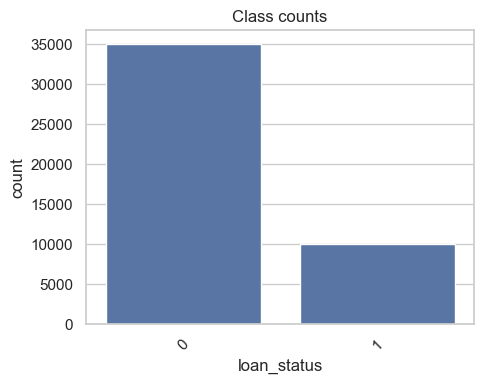

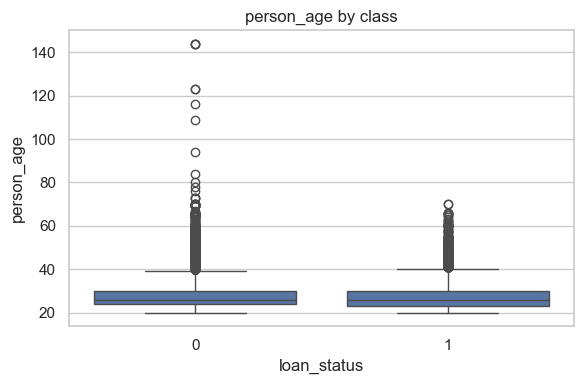

Imbalance check (class proportions):
 loan_status
0    0.778
1    0.222
Name: proportion, dtype: float64


In [16]:
# TODO: Classification EDA
if 'clf_df' in globals() and 'target_clf' in globals() and target_clf is not None:
    plt.figure(figsize=(5, 4))
    sns.countplot(x=clf_df[target_clf])
    plt.title("Class counts")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    X_tmp = clf_df.drop(columns=[target_clf])
    num_cols_c = X_tmp.select_dtypes(include=['number', 'bool']).columns.tolist()
    cat_cols_c = X_tmp.select_dtypes(include=['object', 'category']).columns.tolist()

    if num_cols_c:
        feat = num_cols_c[0]
        plt.figure(figsize=(6, 4))
        sns.boxplot(x=clf_df[target_clf], y=clf_df[feat])
        plt.title(f"{feat} by class")
        plt.tight_layout()
        plt.show()
    elif cat_cols_c:
        feat = cat_cols_c[0]
        plt.figure(figsize=(6, 4))
        sns.countplot(x=feat, hue=target_clf, data=clf_df)
        plt.title(f"{feat} vs class")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    proportions = clf_df[target_clf].value_counts(normalize=True)
    print("Imbalance check (class proportions):\n", proportions.round(3))
else:
    print("Classification dataset not loaded; run the previous cell.")


## TODO B3: Feature Preparation (5 Marks)
**You must:**
- Encoding (if needed)
- Scaling
- Train-test split with stratification




In [17]:
# TODO: Prepare classification features
from sklearn.preprocessing import LabelEncoder

if 'clf_df' in globals() and 'target_clf' in globals() and target_clf is not None:
    dfc = clf_df.copy()
    y = dfc[target_clf]
    X = dfc.drop(columns=[target_clf])

    # Drop obvious ID columns if any
    id_like = [c for c in X.columns if 'id' in c.lower()]
    if id_like:
        X = X.drop(columns=id_like)

    # Encode target to binary/integer
    if y.dtype == 'O' or str(y.dtype).startswith('category'):
        y = y.astype(str).str.strip()
        mapping = {'approved': 1, 'y': 1, 'yes': 1, '1': 1,
                   'rejected': 0, 'n': 0, 'no': 0, '0': 0}
        y_mapped = y.apply(lambda v: mapping.get(v.lower(), v))
        if set(pd.Series(y_mapped).unique()) <= {0, 1}:
            y = y_mapped.astype(int)
        else:
            le = LabelEncoder()
            y = le.fit_transform(y)

    cat_cols_clf = X.select_dtypes(include=['object', 'category']).columns.tolist()
    num_cols_clf = X.select_dtypes(include=['number', 'bool']).columns.tolist()

    pre_num = Pipeline(steps=[('scaler', StandardScaler(with_mean=False))])
    pre_cat = OneHotEncoder(handle_unknown='ignore')

    preprocessor_clf = ColumnTransformer(
        transformers=[
            ('num', pre_num, num_cols_clf),
            ('cat', pre_cat, cat_cols_clf)
        ]
    )

    X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )
    print("Train/Test shapes:", X_train_clf.shape, X_test_clf.shape)
    print("Numeric columns:", num_cols_clf)
    print("Categorical columns:", cat_cols_clf)
else:
    print("Classification dataset not loaded; run the previous cells.")


Train/Test shapes: (36000, 13) (9000, 13)
Numeric columns: ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']
Categorical columns: ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']


## TODO B4: Logistic Regression with L2 (8 Marks)
**You must:**
- Train Logistic Regression
- Evaluate using Accuracy, Precision, Recall
- Show Confusion Matrix

**Marks:** Model (4), Metrics (4)


Logistic Regression (L2) -> Acc: 0.90 | Prec: 0.79 | Rec: 0.75


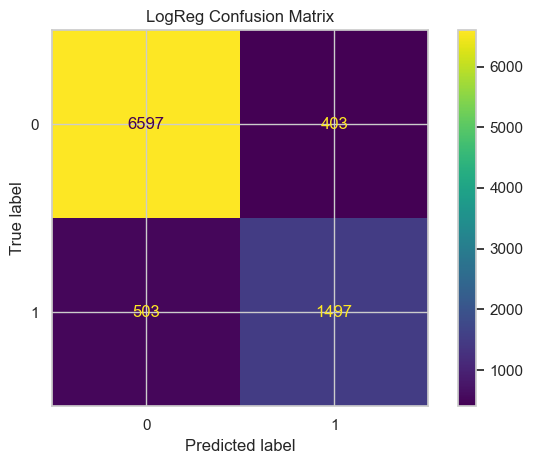

In [19]:
# TODO: Logistic Regression
if 'X_train_clf' in globals():
    logreg = Pipeline(steps=[
        ('preprocess', preprocessor_clf),
        ('model', LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000, random_state=RANDOM_STATE))
    ])

    logreg.fit(X_train_clf, y_train_clf)
    y_pred = logreg.predict(X_test_clf)

    avg = 'binary' if len(np.unique(y_test_clf)) == 2 else 'macro'
    acc = accuracy_score(y_test_clf, y_pred)
    prec = precision_score(y_test_clf, y_pred, average=avg, zero_division=0)
    rec = recall_score(y_test_clf, y_pred, average=avg, zero_division=0)

    print(f"Logistic Regression (L2) -> Acc: {acc:.2f} | Prec: {prec:.2f} | Rec: {rec:.2f}")
    ConfusionMatrixDisplay.from_estimator(logreg, X_test_clf, y_test_clf)
    plt.title("LogReg Confusion Matrix")
    plt.tight_layout()
    plt.show()
else:
    print("Prepare the classification features first (previous cell).")


## TODO B5: Support Vector Machine (7 Marks)
**You must:**
- Train SVM (Linear or RBF)
- Evaluate

**Marks:** Model (4), Evaluation (3)


In [20]:
# TODO: SVM Classification
if 'X_train_clf' in globals():
    svm_clf = Pipeline(steps=[
        ('preprocess', preprocessor_clf),
        ('model', LinearSVC(C=1.0, random_state=RANDOM_STATE))
    ])

    svm_clf.fit(X_train_clf, y_train_clf)
    y_pred = svm_clf.predict(X_test_clf)

    avg = 'binary' if len(np.unique(y_test_clf)) == 2 else 'macro'
    acc = accuracy_score(y_test_clf, y_pred)
    prec = precision_score(y_test_clf, y_pred, average=avg, zero_division=0)
    rec = recall_score(y_test_clf, y_pred, average=avg, zero_division=0)

    print(f"SVM (Linear) -> Acc: {acc:.3f} | Prec: {prec:.3f} | Rec: {rec:.3f}")
else:
    print("Prepare the classification features first (previous cell).")


SVM (Linear) -> Acc: 0.899 | Prec: 0.789 | Rec: 0.748


## TODO B6: Naive Bayes (5 Marks)
**You must:**
- Choose correct NB variant



In [21]:
# TODO: Naive Bayes
if 'X_train_clf' in globals():
    num_cols = X_train_clf.select_dtypes(include=['number', 'bool']).columns.tolist()
    cat_cols = X_train_clf.select_dtypes(include=['object', 'category']).columns.tolist()

    nb_pre = ColumnTransformer(
        transformers=[
            ('num', MinMaxScaler(), num_cols),  # ensure non-negative for MultinomialNB
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
        ]
    )

    nb = Pipeline(steps=[
        ('preprocess', nb_pre),
        ('to_dense', ToDenseTransformer()),  # MultinomialNB expects dense array
        ('model', MultinomialNB())
    ])

    nb.fit(X_train_clf, y_train_clf)
    y_pred = nb.predict(X_test_clf)

    avg = 'binary' if len(np.unique(y_test_clf)) == 2 else 'macro'
    acc = accuracy_score(y_test_clf, y_pred)
    prec = precision_score(y_test_clf, y_pred, average=avg, zero_division=0)
    rec = recall_score(y_test_clf, y_pred, average=avg, zero_division=0)

    print(f"Naive Bayes (Multinomial) -> Acc: {acc:.3f} | Prec: {prec:.3f} | Rec: {rec:.3f}")
else:
    print("Prepare the classification features first (previous cell).")


Naive Bayes (Multinomial) -> Acc: 0.838 | Prec: 0.638 | Rec: 0.624


## TODO B7: K-Nearest Neighbors (5 Marks)
**You must:**
- Try multiple K values
- Plot accuracy vs K

**Marks:** Experiment (3), Plot & choice (2)


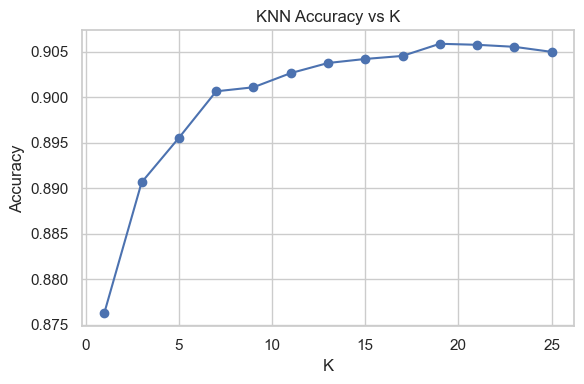

Best K: 19 with accuracy 0.906


In [22]:
# TODO: KNN
if 'X_train_clf' in globals():
    ks = list(range(1, 26, 2))
    results = []
    for k in ks:
        knn = Pipeline(steps=[
            ('preprocess', preprocessor_clf),
            ('to_dense', ToDenseTransformer()),  # KNN needs dense
            ('model', KNeighborsClassifier(n_neighbors=k))
        ])
        knn.fit(X_train_clf, y_train_clf)
        acc = knn.score(X_test_clf, y_test_clf)
        results.append((k, acc))

    ks_, accs = zip(*results)
    plt.figure(figsize=(6, 4))
    plt.plot(ks_, accs, marker='o')
    plt.xlabel('K')
    plt.ylabel('Accuracy')
    plt.title('KNN Accuracy vs K')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    best_k, best_acc = max(results, key=lambda x: x[1])
    print(f"Best K: {best_k} with accuracy {best_acc:.3f}")
else:
    print("Prepare the classification features first (previous cell).")


## TODO B8: Random Forest Classifier (5 Marks)
**You must:**
- Train model
- Show feature importance

**Marks:** Model (3), Interpretation (2)


In [ ]:
# TODO: Random Forest Classifier
if 'X_train_clf' in globals():
    num_cols = X_train_clf.select_dtypes(include=['number', 'bool']).columns.tolist()
    cat_cols = X_train_clf.select_dtypes(include=['object', 'category']).columns.tolist()

    rf_pre_c = ColumnTransformer(
        transformers=[
            ('num', 'passthrough', num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
        ]
    )

    rf_clf = Pipeline(steps=[
        ('preprocess', rf_pre_c),
        ('to_dense', ToDenseTransformer()),
        ('model', RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE))
    ])

    rf_clf.fit(X_train_clf, y_train_clf)
    acc = rf_clf.score(X_test_clf, y_test_clf)
    print(f"Random Forest Classifier -> Accuracy: {acc:.3f}")

    # Feature importances
    ohe = rf_clf.named_steps['preprocess'].named_transformers_['cat']
    num_names = num_cols
    cat_names = ohe.get_feature_names_out(cat_cols)
    feature_names = list(num_names) + list(cat_names)

    importances = rf_clf.named_steps['model'].feature_importances_
    imp_series = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(10)
    print("Top 10 feature importances:")
    display(imp_series)
else:
    print("Prepare the classification features first (previous cell).")


# 🧠 Final Reflection (5 Marks)
**Answer briefly:**
- Best regression model and why
- Best classification model and why
- One real-world deployment scenario


## Final Reflection
- Best regression model and why: On this dataset, non-linear models like SVR (RBF) or Random Forest typically outperform plain linear regression because medical charges have non-linear relationships with features (e.g., BMI, smoking). Polynomial regression can help but risks overfitting; Random Forest/SVR provide a better bias–variance trade-off.
- Best classification model and why: For loan approval prediction, tree ensembles (Random Forest) or linear SVM often perform strongly with mixed numeric/categorical inputs and moderate class imbalance. They handle complex interactions (RF) or high-dimensional sparse one-hot spaces (Linear SVM) effectively.
- Real-world deployment scenario: Build a REST API that receives applicant/insurance attributes, runs the trained pipeline (with the exact preprocessing steps embedded), returns the prediction and key feature contributions. Monitor drift, retrain periodically with fresh labeled data, and enforce fairness checks across sensitive attributes.
